# Forecasting South African Inflation with Macroenomic Variables

## Project Overview
This project aims to forecast South African inflation using historical macroeconomic variables such as past inflation, interest rates, and USD/ZAR exchange rate.

## Goals
- Learn time-series analysis in Python
- Build a simple econometric forecasting model
- Evaluate forecasting performance
- Interpret the economic meaning of the results

# Forecasting South African Inflation with Macroeconomic Variables

This project builds a simple econometric model to forecast South African inflation using macroeconomic indicators.

The model uses:

• Lagged inflation
• Interest rates
• USD/ZAR exchange rate

Using Python and the statsmodels library, the project constructs a regression-based forecasting model and evaluates its predictive accuracy using MAE and RMSE.

The objective is to demonstrate a basic macroeconomic forecasting workflow using time-series data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

## Data Plan

I will build a monthly dataset containing:

- South African inflation (target variable)
- Interest rate
- USD/ZAR exchange rate

The objective is to forecast inflation using lagged macroeconomic variables.

In [7]:
inflation = pd.read_csv("data/sa_inflation.csv")
interest = pd.read_csv("data/sa_interest_rate.csv")
exchange = pd.read_csv("data/usd_zar.csv")

inflation.head()

,observation_date,ZAFCPIALLMINMEI
0,1957-01-01,1.261921
1,1957-02-01,1.261921
2,1957-03-01,1.266444
3,1957-04-01,1.266444
4,1957-05-01,1.270967


In [8]:
inflation.columns = ["date", "inflation"]
interest.columns = ["date", "interest_rate"]
exchange.columns = ["date", "usd_zar"]

In [9]:
inflation["date"] = pd.to_datetime(inflation["date"])
interest["date"] = pd.to_datetime(interest["date"])
exchange["date"] = pd.to_datetime(exchange["date"])

In [10]:
inflation.head()

,date,inflation
0,1957-01-01,1.261921
1,1957-02-01,1.261921
2,1957-03-01,1.266444
3,1957-04-01,1.266444
4,1957-05-01,1.270967


In [11]:
df = pd.merge(inflation, interest, on="date", how="inner")
df = pd.merge(df, exchange, on="date", how="inner")
df.head()

,date,inflation,interest_rate,usd_zar
0,2021-04-01,130.6433,3.5,14.6450
1,2021-06-01,131.1149,3.5,13.7550
2,2021-07-01,132.5298,3.5,14.4375
3,2021-09-01,133.3159,3.5,14.3850
4,2021-10-01,133.7875,3.5,14.8650


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           34 non-null     datetime64[ns]
 1   inflation      34 non-null     float64       
 2   interest_rate  34 non-null     float64       
 3   usd_zar        32 non-null     float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 1.2 KB


In [13]:
df = df.dropna()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 0 to 32
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           32 non-null     datetime64[ns]
 1   inflation      32 non-null     float64       
 2   interest_rate  32 non-null     float64       
 3   usd_zar        32 non-null     float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 1.2 KB


In [18]:
df = df.sort_values("date")
df = df.reset_index(drop = True)
df.head()


,date,inflation,interest_rate,usd_zar
0,2021-04-01,130.6433,3.5,14.6450
1,2021-06-01,131.1149,3.5,13.7550
2,2021-07-01,132.5298,3.5,14.4375
3,2021-09-01,133.3159,3.5,14.3850
4,2021-10-01,133.7875,3.5,14.8650


In [19]:
df.tail()

,date,inflation,interest_rate,usd_zar
27,2024-05-01,156.1116,8.25,18.6203
28,2024-07-01,156.8977,8.25,18.3154
29,2024-08-01,157.0549,8.25,18.1732
30,2024-10-01,157.2121,8.00,17.3832
31,2024-11-01,157.0549,7.93,17.5778


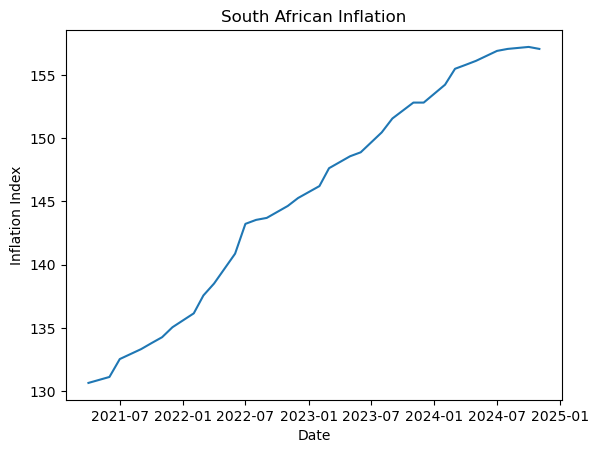

In [20]:
plt.plot(df["date"], df["inflation"])
plt.title("South African Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation Index")
plt.show()

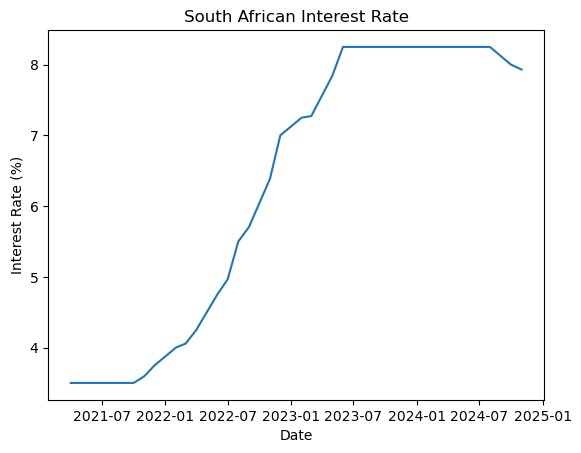

In [21]:
plt.plot(df["date"], df["interest_rate"])
plt.title("South African Interest Rate")
plt.xlabel("Date")
plt.ylabel("Interest Rate (%)")
plt.show()

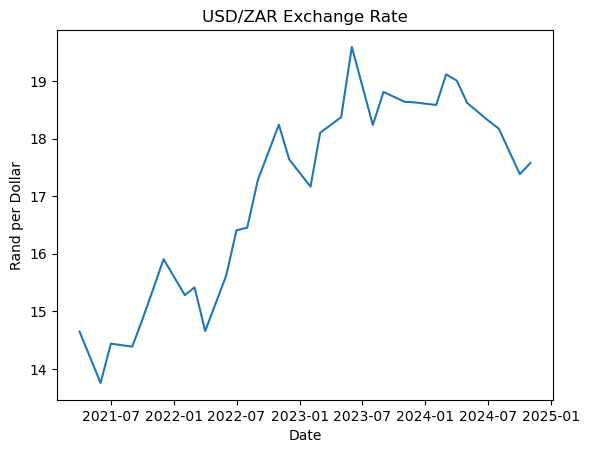

In [22]:
plt.plot(df["date"], df["usd_zar"])
plt.title("USD/ZAR Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Rand per Dollar")
plt.show()

In [115]:
df["inflation_rate"] = df["inflation_index"].pct_change() * 100
df = df.dropna().copy()
df.head()

,month,inflation_index,interest_rate,usd_zar,date,inflation_rate
1,2021-04,130.6433,3.5,14.405259,2021-04-01,0.727294
2,2021-05,130.8005,3.5,14.044250,2021-05-01,0.120328
3,2021-06,131.1149,3.5,13.913068,2021-06-01,0.240366
4,2021-07,132.5298,3.5,14.536190,2021-07-01,1.079130
5,2021-08,133.0014,3.5,14.762273,2021-08-01,0.355844


In [25]:
df = df.dropna()

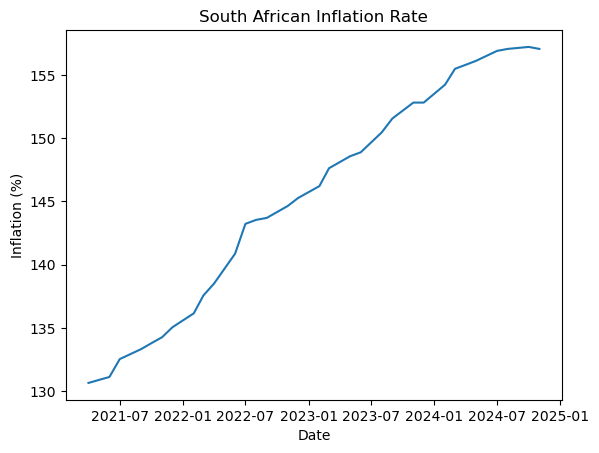

In [27]:
plt.plot(df["date"], df["inflation_rate"])
plt.title("South African Inflation Rate")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.show()

In [28]:
df["inflation_lag1"] = df["inflation_rate"].shift(1)
df["interest_lag1"] = df["interest_rate"].shift(1)
df["usd_zar_lag1"] = df["usd_zar"].shift(1)
df = df.dropna()
df.head()

,date,inflation,interest_rate,usd_zar,inflation_rate,inflation_lag1,interest_lag1,usd_zar_lag1
1,2021-06-01,131.1149,3.500000,13.7550,131.1149,130.6433,3.5,14.6450
2,2021-07-01,132.5298,3.500000,14.4375,132.5298,131.1149,3.5,13.7550
3,2021-09-01,133.3159,3.500000,14.3850,133.3159,132.5298,3.5,14.4375
4,2021-10-01,133.7875,3.500000,14.8650,133.7875,133.3159,3.5,14.3850
5,2021-11-01,134.2591,3.595238,15.3875,134.2591,133.7875,3.5,14.8650


In [30]:
df["inflation_rate"] = df["inflation"].pct_change()*100
df = df.dropna()
df.head()

/tmp/ipykernel_11734/1316233507.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["inflation_rate"] = df["inflation"].pct_change()*100


,date,inflation,interest_rate,usd_zar,inflation_rate,inflation_lag1,interest_lag1,usd_zar_lag1
2,2021-07-01,132.5298,3.500000,14.4375,1.079130,131.1149,3.500000,13.7550
3,2021-09-01,133.3159,3.500000,14.3850,0.593150,132.5298,3.500000,14.4375
4,2021-10-01,133.7875,3.500000,14.8650,0.353746,133.3159,3.500000,14.3850
5,2021-11-01,134.2591,3.595238,15.3875,0.352499,133.7875,3.500000,14.8650
6,2021-12-01,135.0452,3.750000,15.9050,0.585510,134.2591,3.595238,15.3875


In [47]:
X = df[["inflation_lag1", "interest_lag1", "usd_zar_lag1"]]
y = df["inflation_rate"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         inflation_rate   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     2.652
Date:                Thu, 12 Mar 2026   Prob (F-statistic):             0.0697
Time:                        21:48:43   Log-Likelihood:                -13.860
No. Observations:                  30   AIC:                             35.72
Df Residuals:                      26   BIC:                             41.32
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             10.2708      4.463      2.

In [33]:
df["predicted_inflation"] = model.predict(X)
df[["date", "inflation_rate", "predicted_inflation"]].head()

,date,inflation_rate,predicted_inflation
2,2021-07-01,1.079130,1.102005
3,2021-09-01,0.593150,0.937358
4,2021-10-01,0.353746,0.890210
5,2021-11-01,0.352499,0.809402
6,2021-12-01,0.585510,0.751621


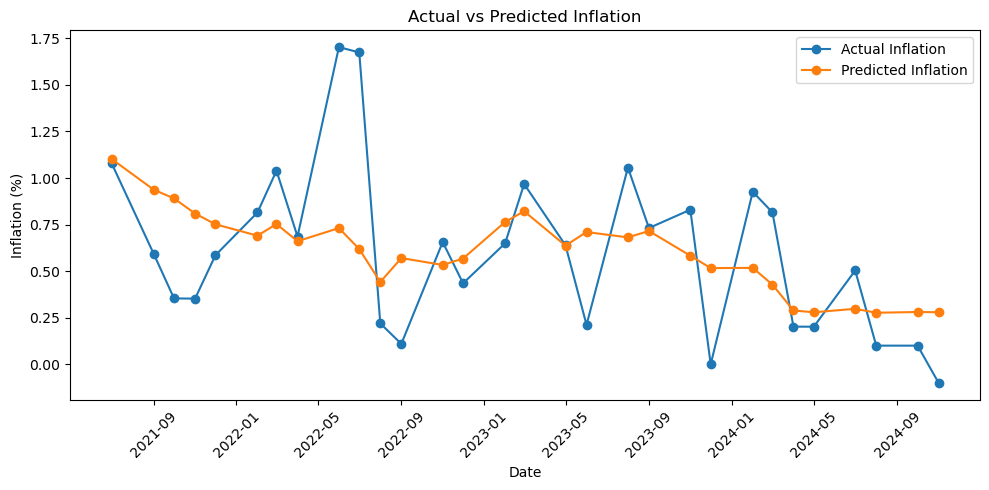

In [40]:
plt.figure(figsize=(10,5))


plt.plot(df["date"], df["inflation_rate"], marker = "o", label = "Actual Inflation")
plt.plot(df["date"], df["predicted_inflation"], marker = "o", label = "Predicted Inflation")

plt.title("Actual vs Predicted Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")

plt.xticks(rotation = 45)
plt.tight_layout()

plt.legend()
plt.show()

In [41]:
mae = mean_absolute_error(df["inflation_rate"], df["predicted_inflation"])
rmse = mean_squared_error(df["inflation_rate"], df["predicted_inflation"]) ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.29149926271121057
RMSE: 0.3840632164317369


## Forecast Accuracy

The model's forecast accuracy was evaluated using MAE and RMSE.

-MAE measures the average absolute difference between actual and predicted inflation.

-RMSE give the greater weight to larger prediction errors.

The predicted series tracks the general movement of inflation, but it is smoother than the actual series and misses some short term spikes.

In [49]:
df["inflation_lag2"] = df["inflation_rate"].shift(2)
df = df.dropna().copy()

X = df[["inflation_lag1", "inflation_lag2", "interest_lag1","usd_zar_lag1"]]
y = df["inflation_rate"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         inflation_rate   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     3.520
Date:                Thu, 12 Mar 2026   Prob (F-statistic):             0.0238
Time:                        21:54:03   Log-Likelihood:                -9.8555
No. Observations:                  26   AIC:                             29.71
Df Residuals:                      21   BIC:                             36.00
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             15.6181      5.168      3.

In [53]:
df["predicted_inflation"] = model.predict(X)

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(df["inflation_rate"], df["predicted_inflation"])
rmse = mean_squared_error(df["inflation_rate"], df["predicted_inflation"]) ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.2823201233989439
RMSE: 0.3534972935161619


In [55]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]


X_train = train[["inflation_lag1","inflation_lag2","interest_lag1","usd_zar_lag1"]]
y_train = train["inflation_rate"]

X_train = sm.add_constant(X_train)


X_test = test[["inflation_lag1","inflation_lag2","interest_lag1","usd_zar_lag1"]]
y_test = test["inflation_rate"]

X_test = sm.add_constant(X_test)


model = sm.OLS(y_train, X_train).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         inflation_rate   R-squared:                       0.315
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     1.725
Date:                Thu, 12 Mar 2026   Prob (F-statistic):              0.197
Time:                        22:02:50   Log-Likelihood:                -7.8128
No. Observations:                  20   AIC:                             25.63
Df Residuals:                      15   BIC:                             30.60
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.6183      8.568      1.

In [119]:
test.loc[:, "predicted_inflation"] = model.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, test["predicted_inflation"])
rmse = np.sqrt(mean_squared_error(y_test, test["predicted_inflation"]))

print("Test MAE:", mae)
print("Test RMSE:", rmse)

Test MAE: 0.48703170275325797
Test RMSE: 0.6336207246152848


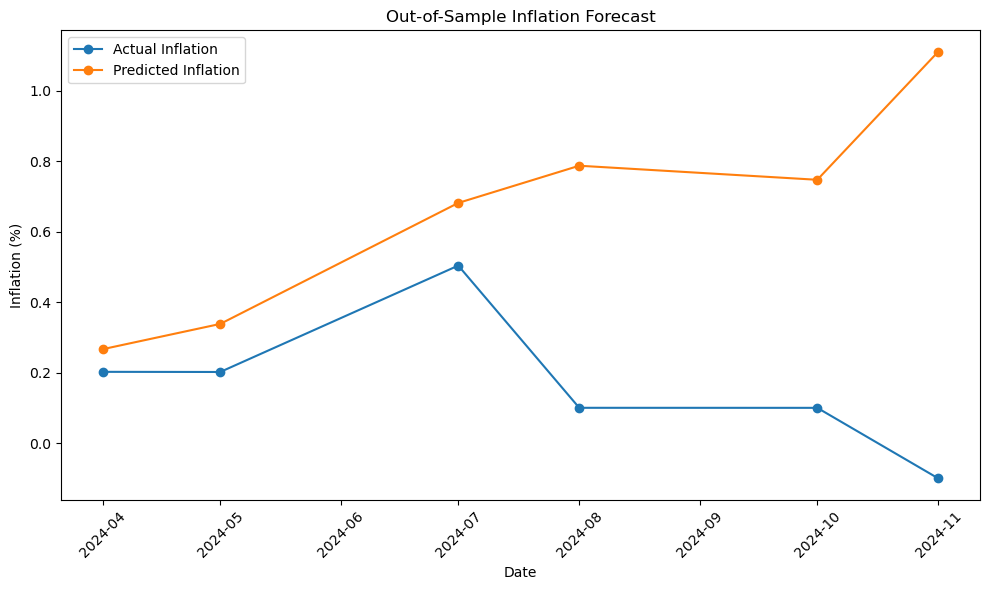

In [59]:
plt.figure(figsize=(10,6))

plt.plot(test["date"], y_test, marker="o", label="Actual Inflation")
plt.plot(test["date"], test["predicted_inflation"], marker="o", label="Predicted Inflation")

plt.title("Out-of-Sample Inflation Forecast")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [69]:
arima_df = df[["date", "inflation_rate"]].copy()
arima_df["date"] = pd.to_datetime(arima_df["date"])
arima_df = arima_df.sort_values("date")
arima_df = arima_df.set_index("date")
arima_df = arima_df.asfreq("MS")

arima_df["inflation_rate"] = arima_df["inflation_rate"].interpolate()

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(arima_df["inflation_rate"], order=(2, 0, 1))
arima_results = arima_model.fit()

print(arima_results.summary())

forecast = arima_results.forecast(steps=6)
print(forecast)

                               SARIMAX Results                                
Dep. Variable:         inflation_rate   No. Observations:                   36
Model:                 ARIMA(2, 0, 1)   Log Likelihood                 -12.029
Date:                Thu, 12 Mar 2026   AIC                             34.058
Time:                        22:10:41   BIC                             41.975
Sample:                    12-01-2021   HQIC                            36.821
                         - 11-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5921      0.117      5.067      0.000       0.363       0.821
ar.L1          0.4336      0.751      0.578      0.563      -1.038       1.905
ar.L2         -0.1551      0.438     -0.354      0.7

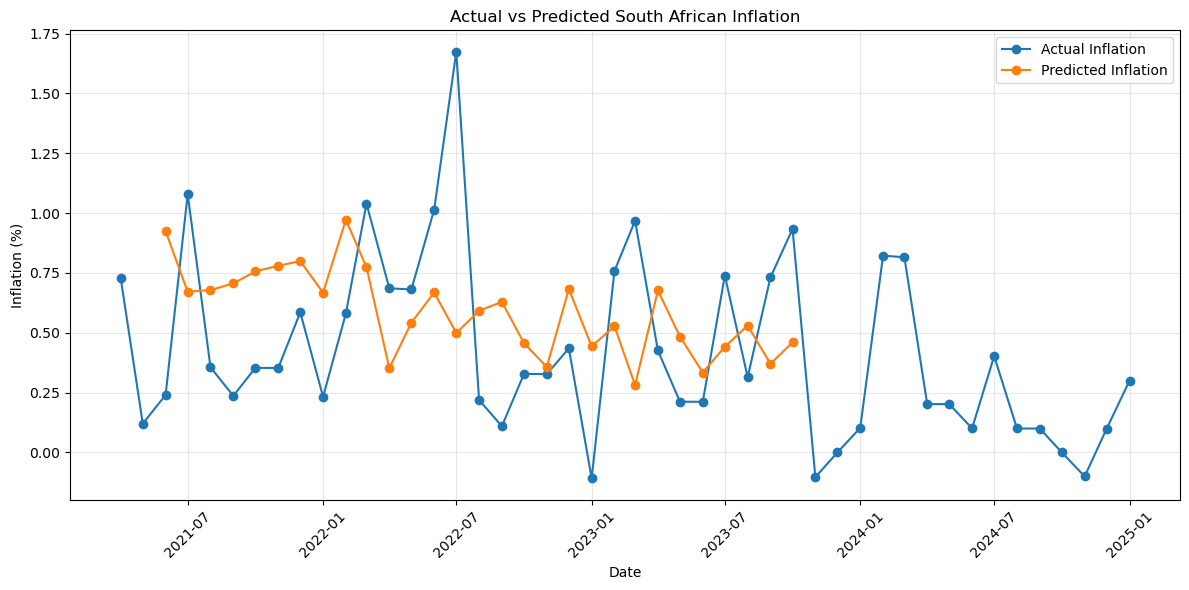

In [117]:
df["predicted_inflation"] = model.predict(X)

plt.figure(figsize=(12,6))

plt.plot(df["date"], df["inflation_rate"], label="Actual Inflation", marker="o")
plt.plot(df["date"], df["predicted_inflation"], label="Predicted Inflation", marker="o")

plt.title("Actual vs Predicted South African Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Conclusion

This project developed a simple econometric model to forecast South African inflation using lagged inflation, interest rates, and the USD/ZAR exchange rate.

The model captures the general direction of inflation but fails to replicate short-term volatility and sharp inflation spikes. This is expected because inflation is influenced by many external shocks such as energy prices and global economic conditions.

Evaluation metrics show a mean absolute error of approximately 0.49 percentage points, suggesting the model provides a reasonable approximation but is not suitable for high-precision forecasting.

Future improvements could include additional macroeconomic variables such as oil prices, food inflation indices, or global commodity prices, as well as more advanced time-series models such as ARIMA or VAR models.